In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [17]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.5 * X **2 + 0.8 * X + 2 + np.random.randn(200, 1) 

Text(0, 0.5, 'y')

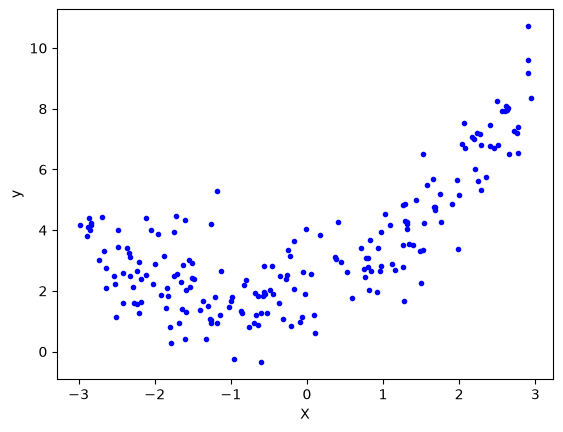

In [18]:
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(r2_score(y_test, y_pred))

0.46546841371933045


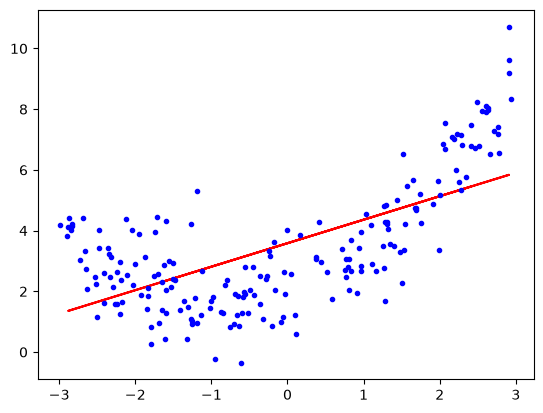

In [20]:
plt.plot(X_train, lr.predict(X_train),color= 'r')
plt.plot(X,y,'b.')
plt.show()

In [21]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [22]:
print(X_train[0])
print(X_train_poly[0])


[-1.59192939]
[ 1.         -1.59192939  2.5342392 ]


In [23]:
lr.fit(X_train_poly, y_train)
y_pred_poly = lr.predict(X_test_poly)
print(r2_score(y_test, y_pred_poly))

0.8359823520728515


In [24]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.8039667  0.47629289]]
[2.15779237]


In [25]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

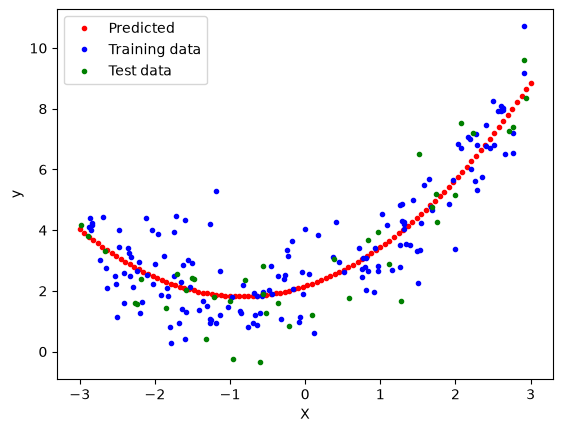

In [30]:
plt.plot(X_new, y_new,'r.',label='Predicted')
plt.plot(X_train,y_train,'b.',label='Training data')
plt.plot(X_test,y_test,'g.',label='Test data')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()    
plt.show()